# Forward Polymarket execution evaluation

## Executive summary

This notebook evaluates a frozen forward strategy using the finalized monthly Polymarket transaction files created by notebook `03_forward_polymarket_data_collection.ipynb`. It automatically discovers every available league-month file for the configured season, combines the observations, and processes orders, fills, and settlements chronologically.

Football-Data and the published frozen parameters determine **which matches qualify** and provide the model probability. Polymarket affects **execution only**. This separation prevents execution prices or subsequent outcomes from changing the statistical signal.

The exercise is a transaction-based historical traded-flow simulation. Historical Dune transactions establish that specified quantities traded at particular times and prices; they are not historical order-book snapshots and do not prove that a hypothetical order would have obtained those fills.

## 1. Frozen execution methodology

For every selected fixture, notebook 03 has already fixed the Football-Data reference odds `MaxH` and frozen model probability $\widehat q_{FD}$. This notebook requires an after-cost execution premium:

$$
O_{\min}=MaxH\,(1+\texttt{MIN\_ODDS\_PREMIUM}),
\qquad
p_{\max}=\frac{1}{O_{\min}}.
$$

Both canonical YES transaction flows are retained:

- **historical taker BUY / maker SELL:** use the observed transaction price;
- **historical taker SELL / maker BUY:** the observed trade must reach the predefined raw limit, but the hypothetical fill is credited only at that limit—not at a more favourable future observed price.

The same configured buyer-side taker fee is charged exactly once in both cases. For seller-initiated historical flow, the raw limit is solved so that the raw price plus the modeled fee equals $p_{\max}$.

Orders are created at the documented Football-Data release time. Subsequent eligible trade observations are processed chronologically, subject to the target stake, partial fills, the per-trade participation cap, available cash, and aggregate unsettled-exposure cap. Positions settle at the configured approximation after kickoff.

## 2. Configuration

The input is the holdout cache folder, not an individual month. Adding a newly finalized league-month file from notebook 03 automatically extends the evaluation the next time this notebook is run.

These settings define the forward execution protocol and should not be retuned in response to observed performance. The aggregate open-exposure cap allows up to 100% of current capital to be committed, while available cash prevents leverage or a negative cash balance; the 5% maximum Kelly stake per match remains unchanged.

In [1]:
from __future__ import annotations

import sys
from dataclasses import asdict
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / "pyproject.toml").exists():
        PROJECT_ROOT = candidate
        break

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from football_edge.forward_execution import (
    ExecutionConfig,
    cache_coverage_by_league,
    evaluate_execution_by_league,
    evaluate_execution_trades,
    holdout_evaluation_period,
    load_finalized_holdout_cache,
    order_strategy_rows_for_display,
    prepare_execution_trades,
    round_numeric_for_display,
    separate_common_strategy_statistics,
)
from football_edge.plotting import plot_forward_execution_results

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 120)

In [2]:
HOLDOUT_CACHE_DIR = PROJECT_ROOT / "data" / "holdout" / "dune_cache"
CURRENT_SEASON = "26_27"
ODDS_SOURCE = "market_maximum"
MARKET_OUTCOME = "home_win"

EXECUTION_CONFIG = ExecutionConfig(
    initial_capital_usd=100_000.0,
    flat_stake_usd=1000.0,
    kelly_fractions=(0.10, 0.25),
    buyer_fee_rate=0.05,
    minimum_odds_premium=0.01,
    allow_partial_fills=True,
    minimum_fill_fraction=0.0,
    maximum_trade_participation=0.50,
    maximum_kelly_stake_fraction=0.05,
    maximum_open_exposure_fraction=1.0,
    assumed_match_duration_hours=2.0,
    reporting_timezone="Europe/London",
    weekly_frequency="W-MON",  # Tuesday-Monday weeks
    monthly_frequency="M",
    weekly_risk_free_rate=0.0,
)

print("Frozen forward execution configuration:")
display(pd.DataFrame([asdict(EXECUTION_CONFIG)]))

Frozen forward execution configuration:


,initial_capital_usd,flat_stake_usd,kelly_fractions,buyer_fee_rate,minimum_odds_premium,allow_partial_fills,minimum_fill_fraction,maximum_trade_participation,maximum_kelly_stake_fraction,maximum_open_exposure_fraction,assumed_match_duration_hours,reporting_timezone,weekly_frequency,monthly_frequency,weekly_risk_free_rate
0,100000.0,1000.0,"(0.1, 0.25)",0.05,0.01,True,0.0,0.5,0.05,1.0,2.0,Europe/London,W-MON,M,0.0


## 3. Discover finalized monthly inputs

Only files ending in `_eligible_trades.csv` and `_match_summary.csv` for the configured season, source, and outcome are loaded. Older experimental cache formats are ignored. Empty league-month trade files are valid and do not stop the report.

In [3]:
holdout_cache = load_finalized_holdout_cache(
    HOLDOUT_CACHE_DIR,
    season=CURRENT_SEASON,
    source=ODDS_SOURCE,
    market_outcome=MARKET_OUTCOME,
)

period = holdout_evaluation_period(holdout_cache)
print(f"Holdout folder: {HOLDOUT_CACHE_DIR.relative_to(PROJECT_ROOT)}")
print(f"Eligible-trade files discovered: {len(holdout_cache.eligible_trade_files):,}")
print(f"Match-summary files discovered: {len(holdout_cache.match_summary_files):,}")
print(f"Evaluation period: {period['evaluation_start']} to {period['evaluation_end']}")
print(f"Last included month: {period['last_included_month']}")
print(f"Football-Data-selected matches: {period['football_data_selected_matches']:,}")
print(f"Base-eligible transaction rows: {period['cached_base_eligible_trade_rows']:,}")

coverage_by_league = cache_coverage_by_league(holdout_cache)
if not coverage_by_league.empty:
    display(round_numeric_for_display(coverage_by_league))
if not holdout_cache.eligible_trade_files:
    print("No finalized eligible-trade files are available yet. Run notebook 03 for a completed month.")

Holdout folder: data\holdout\dune_cache
Eligible-trade files discovered: 3
Match-summary files discovered: 3
Evaluation period: 2026-08-09 to 2026-08-31
Last included month: 2026-08
Football-Data-selected matches: 22
Base-eligible transaction rows: 2,666


,league,football_data_selected_matches,polymarket_markets_resolved,matches_with_base_eligible_trades,base_eligible_trade_rows
0,Greek Super League,3,3,3,34
1,La Liga,13,13,9,2218
2,Primeira Liga,6,6,5,414


## 4. Construct execution opportunities

Notebook 03 applies the base `effective odds >= MaxH` collection threshold. This section reconstructs the public execution assumptions, applies the configured buyer-side fee exactly once, and then enforces `MaxH * (1 + minimum odds premium)`.

No Polymarket price is used to recompute `q_hat_fd`; Kelly sizing uses only the frozen Football-Data model probability and the predefined minimum acceptable odds.

In [4]:
execution_trades, execution_diagnostics = prepare_execution_trades(
    holdout_cache.eligible_trades,
    config=EXECUTION_CONFIG,
)

print(f"Cached base-eligible rows: {len(holdout_cache.eligible_trades):,}")
print(f"Unique canonical transaction rows: {len(execution_trades):,}")
if not execution_trades.empty:
    print(
        "Historical taker SELL / maker BUY rows: "
        f"{execution_trades['historical_trade_type'].eq('taker_sell__maker_buy').sum():,}"
    )
    print(
        "Historical taker BUY / maker SELL rows: "
        f"{execution_trades['historical_trade_type'].eq('taker_buy__maker_sell').sum():,}"
    )
    print(f"Rows passing the frozen execution policy: {execution_trades['execution_eligible'].sum():,}")
if not execution_diagnostics.empty:
    audit_columns = [
        "match_date",
        "league",
        "home_team",
        "away_team",
        "football_data_max_home_odds",
        "canonical_trade_rows",
        "price_evidence_eligible_rows",
        "execution_eligible_rows",
        "taker_sell_maker_buy_rows",
        "taker_buy_maker_sell_rows",
        "maximum_price_reconstruction_error",
        "condition_id",
    ]
    audit_table = execution_diagnostics.reindex(columns=audit_columns).rename(
        columns={"football_data_max_home_odds": "MaxH"}
    )
    audit_table["match_date"] = pd.to_datetime(
        audit_table["match_date"], errors="coerce"
    ).dt.strftime("%Y-%m-%d")
    display(round_numeric_for_display(audit_table, decimals=6))

Cached base-eligible rows: 2,666
Unique canonical transaction rows: 2,666
Historical taker SELL / maker BUY rows: 2,575
Historical taker BUY / maker SELL rows: 91
Rows passing the frozen execution policy: 1,681


,match_date,league,home_team,away_team,MaxH,canonical_trade_rows,price_evidence_eligible_rows,execution_eligible_rows,taker_sell_maker_buy_rows,taker_buy_maker_sell_rows,maximum_price_reconstruction_error,condition_id
0,2026-08-09,Primeira Liga,Benfica,Academico Viseu,1.13,36,0,0,36,0,0.0,0x9f325f8ecb3478ac2bd22a80cd5ef08fa3bcf4bc017221d01fd5a489b8b777ff
1,2026-08-09,Primeira Liga,Porto,Alverca,1.20,185,81,81,184,1,0.0,0xe0671904c101ba5bf14588dae00b7db0463bd2c6aa210985b2e1df952857af5f
2,2026-08-14,Primeira Liga,Sp Lisbon,Guimaraes,1.35,62,54,54,59,3,0.0,0x480834fc087a542e67aae4be2bb2c864f40abe3d3ac460bb11febd4a8340e21d
3,2026-08-16,La Liga,Espanol,Levante,2.10,208,67,67,198,10,0.0,0x091cf26c853682dbdc91ee38d63b1838801842992bdd4dc761b39cffc531e106
4,2026-08-19,La Liga,Ath Madrid,Malaga,1.33,908,813,813,865,43,0.0,0x02c913fd89ec97f63af1a3b2ce975def0d13163635f451fb0c8226f867daaa00
5,2026-08-21,La Liga,Betis,Sociedad,2.12,117,25,25,113,4,0.0,0xcaeaab3b3d1b538f0d1742660fdee9dbbc338affc991167e1bb5c5e7933173b3
6,2026-08-22,Greek Super League,AEK,Iraklis,1.21,10,5,5,10,0,0.0,0x0f907ab97de8dbd030a916a18e22506b2609ba6947cd4cb9772d1d5d67b9c5bc
7,2026-08-22,Greek Super League,Olympiakos,Atromitos,1.26,1,0,0,1,0,0.0,0x55361ffa58e7c13f10e10ed5d5a2c056c04ce402ef295d8163918e21eff72c24
8,2026-08-22,La Liga,Ath Bilbao,Sevilla,1.73,131,66,66,126,5,0.0,0x2cf8b110360af03a4a02186d6f55b7ee9d2bcbfb762dc08bf4e06e7393f6007d
9,2026-08-23,Greek Super League,PAOK,Levadeiakos,1.38,23,9,9,23,0,0.0,0x76f26336326b8bae3d947e5a96b1f2f2dcaf5eb6afbf1d8884e423ee17b68a50


## 5. Combined portfolio results

All leagues and months are combined into one chronological event stream sharing one bankroll and one aggregate exposure constraint. Weekly Tuesday–Monday bankroll returns are used for annualized volatility and Sharpe; monthly returns are used for presentation.

For month $m$, Stake ROI is

$$
\text{Stake ROI}_m = 100 \times \frac{\sum_{i \in m} \text{profit}_i}{\sum_{i \in m} \text{filled stake}_i}.
$$

Stake ROI measures profit per dollar actually wagered, whereas bankroll return measures the change in portfolio capital. They are complementary and should not be interpreted interchangeably. A month with no filled stake has undefined (`NaN`) Stake ROI.

In [5]:
portfolio_evaluation = evaluate_execution_trades(
    execution_trades,
    config=EXECUTION_CONFIG,
)

metric_columns = [
    "strategy",
    "cumulative_return_pct",
    "stake_roi_pct",
    "max_drawdown_pct",
    "annualized_weekly_sharpe",
    "annualized_weekly_volatility_pct",
    "mean_weekly_return_pct",
    "weeks_observed",
    "mean_fill_fraction",
    "filled_stake_usd",
    "profit_usd",
    "final_bankroll_usd",
]

if portfolio_evaluation.metrics.empty:
    print("No settled transaction-based executions are available under this configuration.")
else:
    common_sample, strategy_metrics = separate_common_strategy_statistics(
        portfolio_evaluation.metrics
    )
    if not common_sample.empty:
        print("Common execution/sample statistics across strategies:")
        display(round_numeric_for_display(common_sample))
        strategy_metric_columns = metric_columns
    else:
        strategy_metric_columns = [
            "strategy", "bets", "wins", "hit_rate_pct", *metric_columns[1:]
        ]
    strategy_metrics = order_strategy_rows_for_display(strategy_metrics)
    display(
        round_numeric_for_display(
            strategy_metrics.reindex(columns=strategy_metric_columns)
        )
    )
    print("Monthly bankroll return, Stake ROI, and executed-bet count:")
    monthly_display = order_strategy_rows_for_display(
        portfolio_evaluation.monthly_returns, group_columns=("month",)
    )
    display(round_numeric_for_display(monthly_display))

Common execution/sample statistics across strategies:


,bets,wins,hit_rate_pct
0,11,8,72.7273


,strategy,cumulative_return_pct,stake_roi_pct,max_drawdown_pct,annualized_weekly_sharpe,annualized_weekly_volatility_pct,mean_weekly_return_pct,weeks_observed,mean_fill_fraction,filled_stake_usd,profit_usd,final_bankroll_usd
0,flat stake,1.1168,14.3047,1.6944,2.3423,6.2344,0.2808,4,0.7097,7807.1045,1116.7860,101116.7860
1,10% Kelly,1.7815,19.2011,0.5338,8.8600,2.5995,0.4429,4,0.7382,9278.1561,1781.5125,101781.5125
2,25% Kelly,3.9386,18.5412,1.3286,8.0179,6.3122,0.9733,4,0.7237,21242.5199,3938.6213,103938.6213


Monthly bankroll return, Stake ROI, and executed-bet count:


,strategy,month,bets,filled_stake_usd,profit_usd,stake_roi_pct,start_bankroll_usd,end_bankroll_usd,bankroll_return_pct
0,flat stake,2026-08,11,7807.1045,1116.7860,14.3047,100000.0,101116.7860,1.1168
1,10% Kelly,2026-08,11,9278.1561,1781.5125,19.2011,100000.0,101781.5125,1.7815
2,25% Kelly,2026-08,11,21242.5199,3938.6213,18.5412,100000.0,103938.6213,3.9386


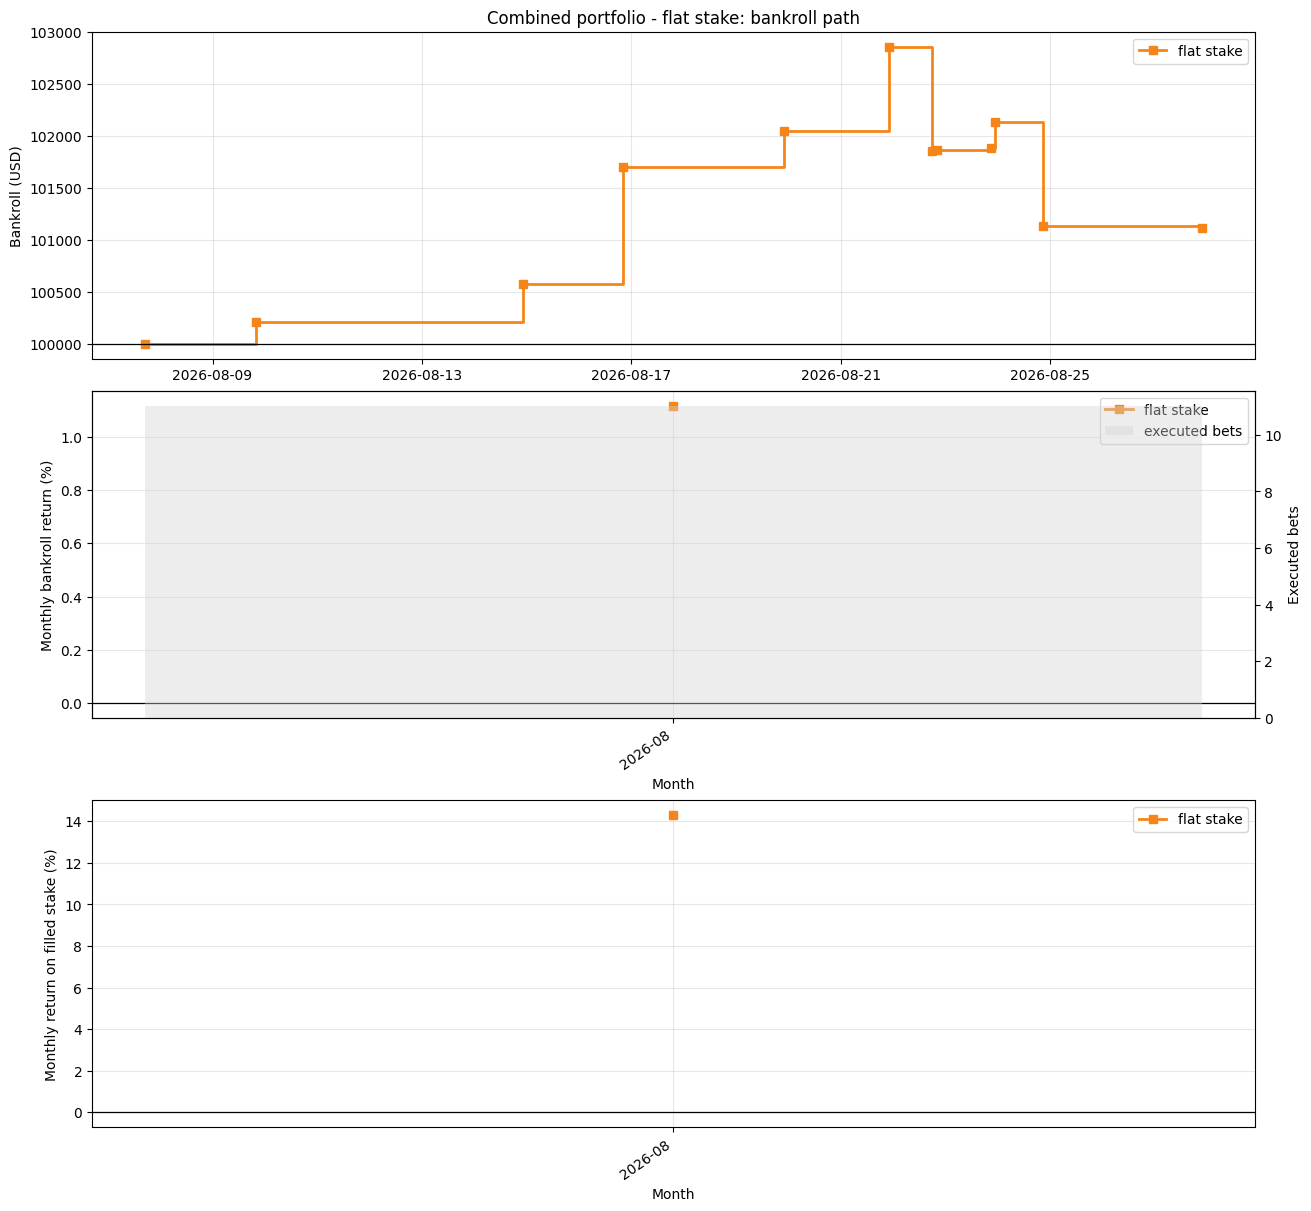

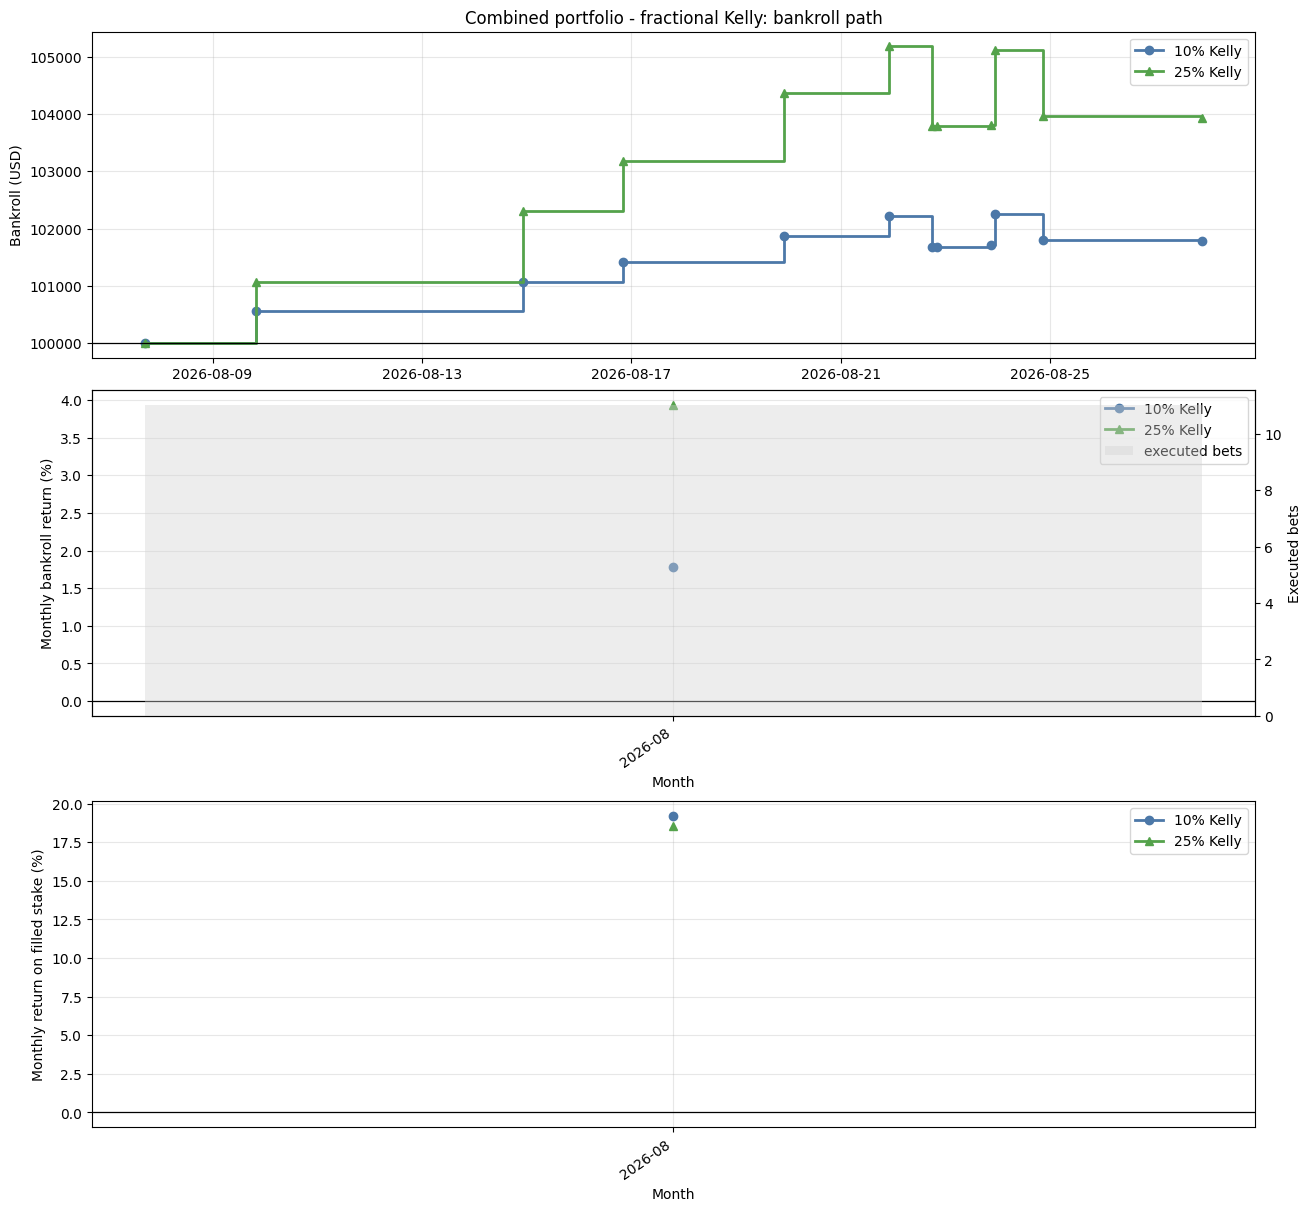

In [6]:
if not portfolio_evaluation.monthly_returns.empty:
    plot_forward_execution_results(
        portfolio_evaluation.simulation.bankroll_paths,
        portfolio_evaluation.monthly_returns,
        strategies=["flat stake"],
        title="Combined portfolio - flat stake",
        initial_capital_usd=EXECUTION_CONFIG.initial_capital_usd,
        reporting_timezone=EXECUTION_CONFIG.reporting_timezone,
    )
    plt.show()

    plot_forward_execution_results(
        portfolio_evaluation.simulation.bankroll_paths,
        portfolio_evaluation.monthly_returns,
        strategies=[f"{fraction:.0%} Kelly" for fraction in EXECUTION_CONFIG.kelly_fractions],
        title="Combined portfolio - fractional Kelly",
        initial_capital_usd=EXECUTION_CONFIG.initial_capital_usd,
        reporting_timezone=EXECUTION_CONFIG.reporting_timezone,
    )
    plt.show()

## 6. Standalone league sleeves

Each league is rerun independently with the full configured initial capital. This makes within-league paths and risk statistics interpretable, but the league results do **not** mechanically decompose the combined portfolio: they use separate bankroll sleeves and do not share the combined portfolio's cross-league exposure constraint.

Common execution/sample statistics within each league:


,analysis_league,bets,wins,hit_rate_pct
0,Greek Super League,2,2,100.0
1,La Liga,6,3,50.0
2,Primeira Liga,3,3,100.0


,analysis_league,strategy,cumulative_return_pct,stake_roi_pct,max_drawdown_pct,annualized_weekly_sharpe,annualized_weekly_volatility_pct,mean_weekly_return_pct,weeks_observed,mean_fill_fraction,filled_stake_usd,profit_usd,final_bankroll_usd
0,Greek Super League,flat stake,0.0254,34.9117,0.0000,NaN,NaN,0.0254,1,0.0363,72.6291,25.3561,100025.3561
1,Greek Super League,10% Kelly,0.0254,34.9117,0.0000,NaN,NaN,0.0254,1,0.0318,72.6291,25.3561,100025.3561
2,Greek Super League,25% Kelly,0.0254,34.9117,0.0000,NaN,NaN,0.0254,1,0.0128,72.6291,25.3561,100025.3561
3,La Liga,flat stake,0.2605,5.5029,1.9755,0.6611,7.0766,0.0900,3,0.7891,4734.4754,260.5328,100260.5328
4,La Liga,10% Kelly,0.1417,4.7783,0.9997,1.2647,1.9515,0.0475,3,0.8430,2966.0279,141.7251,100141.7251
5,La Liga,25% Kelly,0.3124,4.2263,2.4572,1.0845,5.0657,0.1057,3,0.8263,7390.6812,312.3555,100312.3555
6,Primeira Liga,flat stake,0.8309,27.6966,0.0000,24.9243,0.5763,0.2762,3,1.0000,3000.0000,830.8972,100830.8972
7,Primeira Liga,10% Kelly,1.6100,26.0003,0.0000,109.9125,0.2526,0.5338,3,1.0000,6192.2750,1610.0083,101610.0083
8,Primeira Liga,25% Kelly,3.5967,26.5770,0.0000,78.3355,0.7865,1.1848,3,1.0000,13532.9454,3596.6568,103596.6568


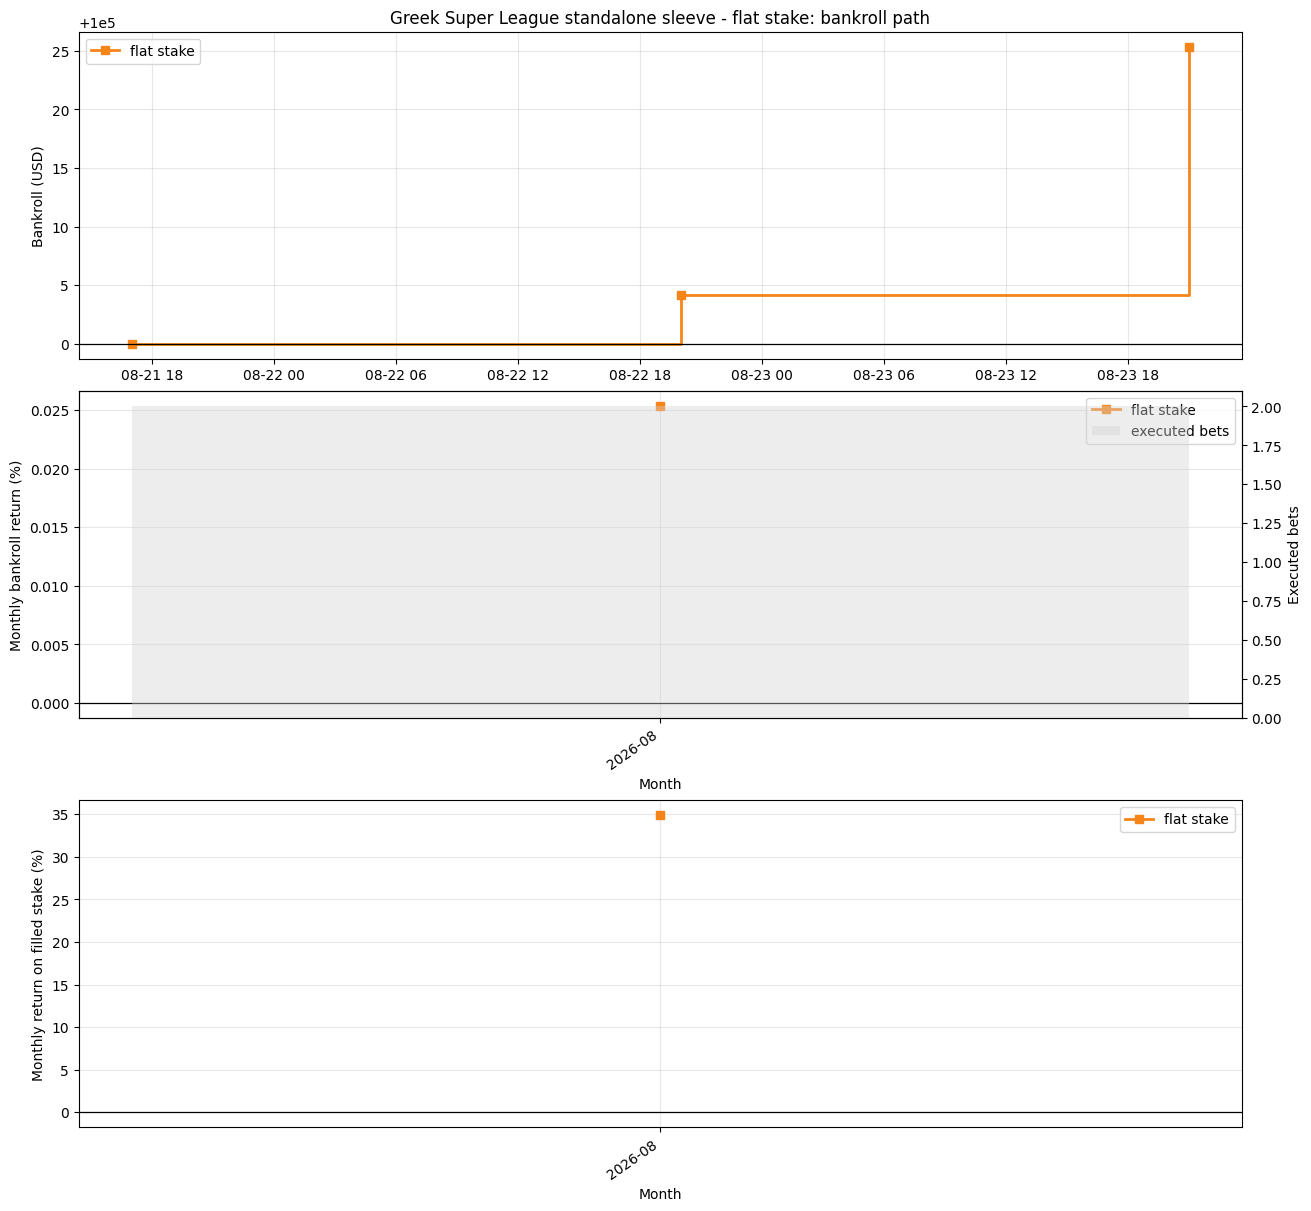

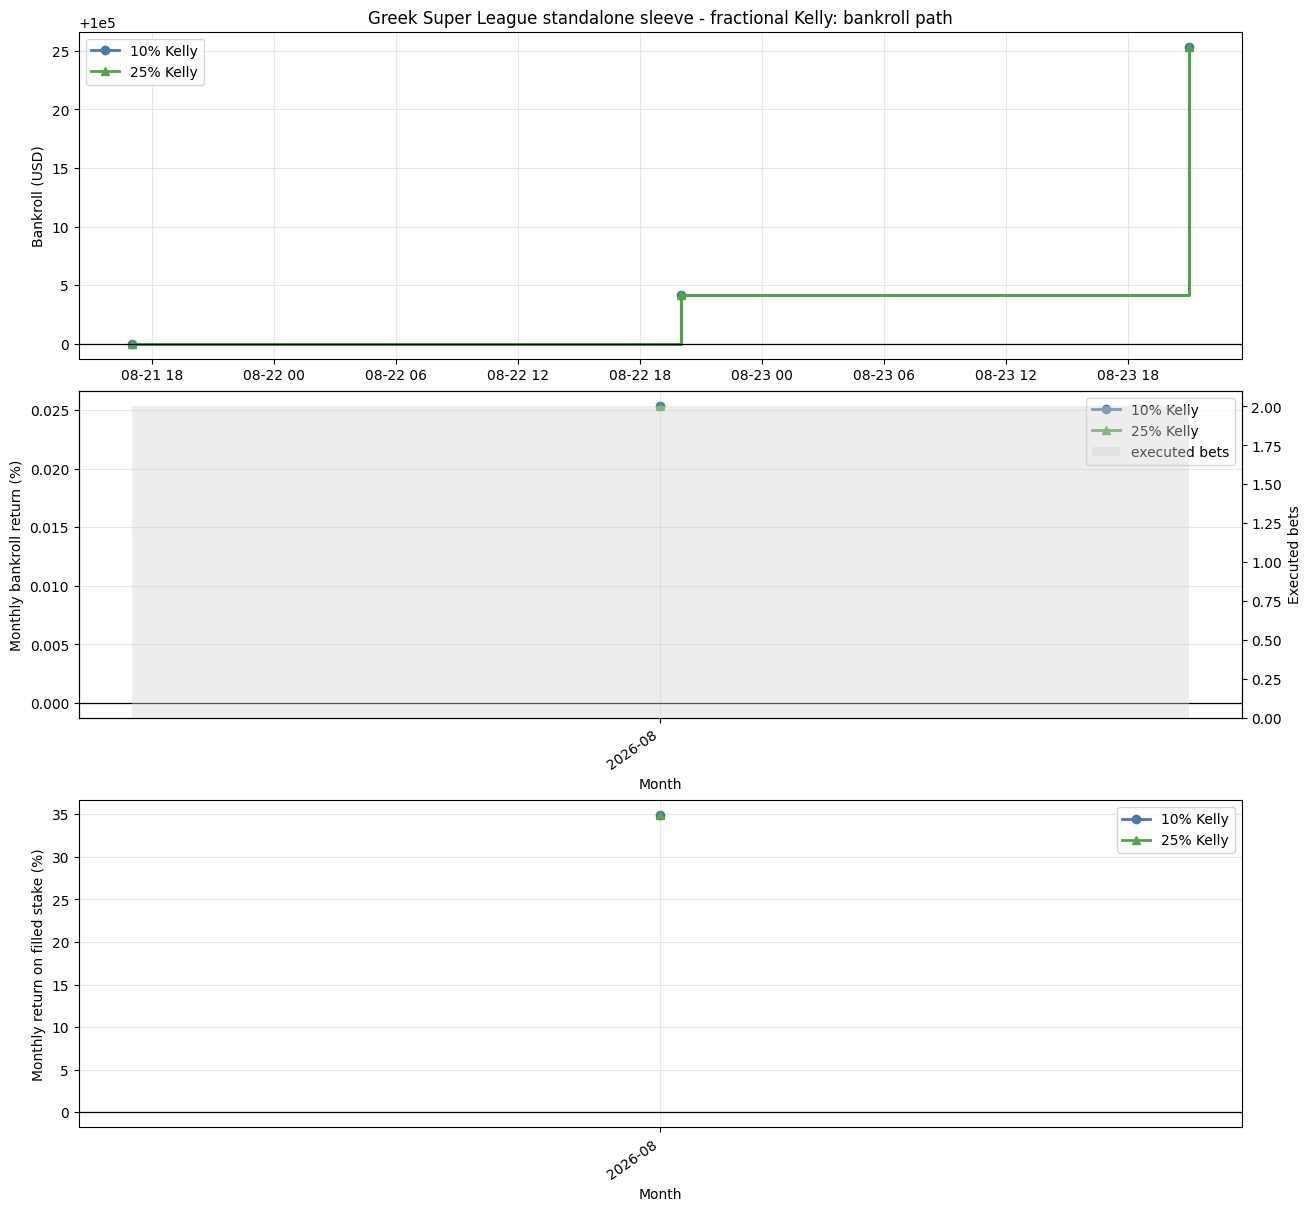

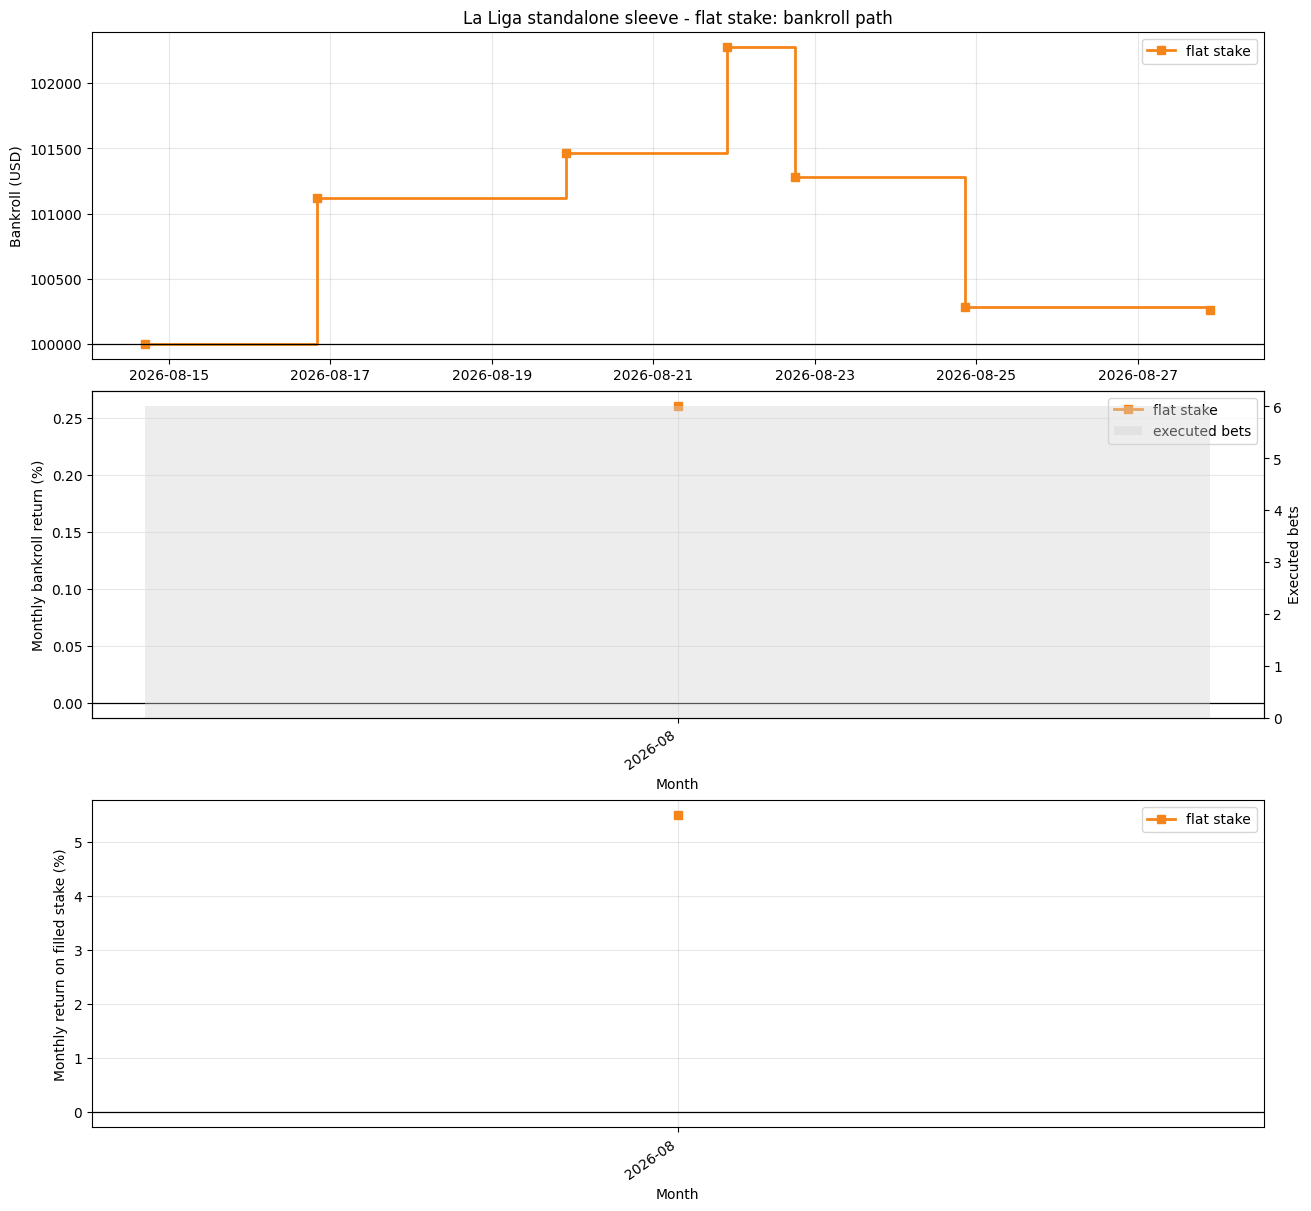

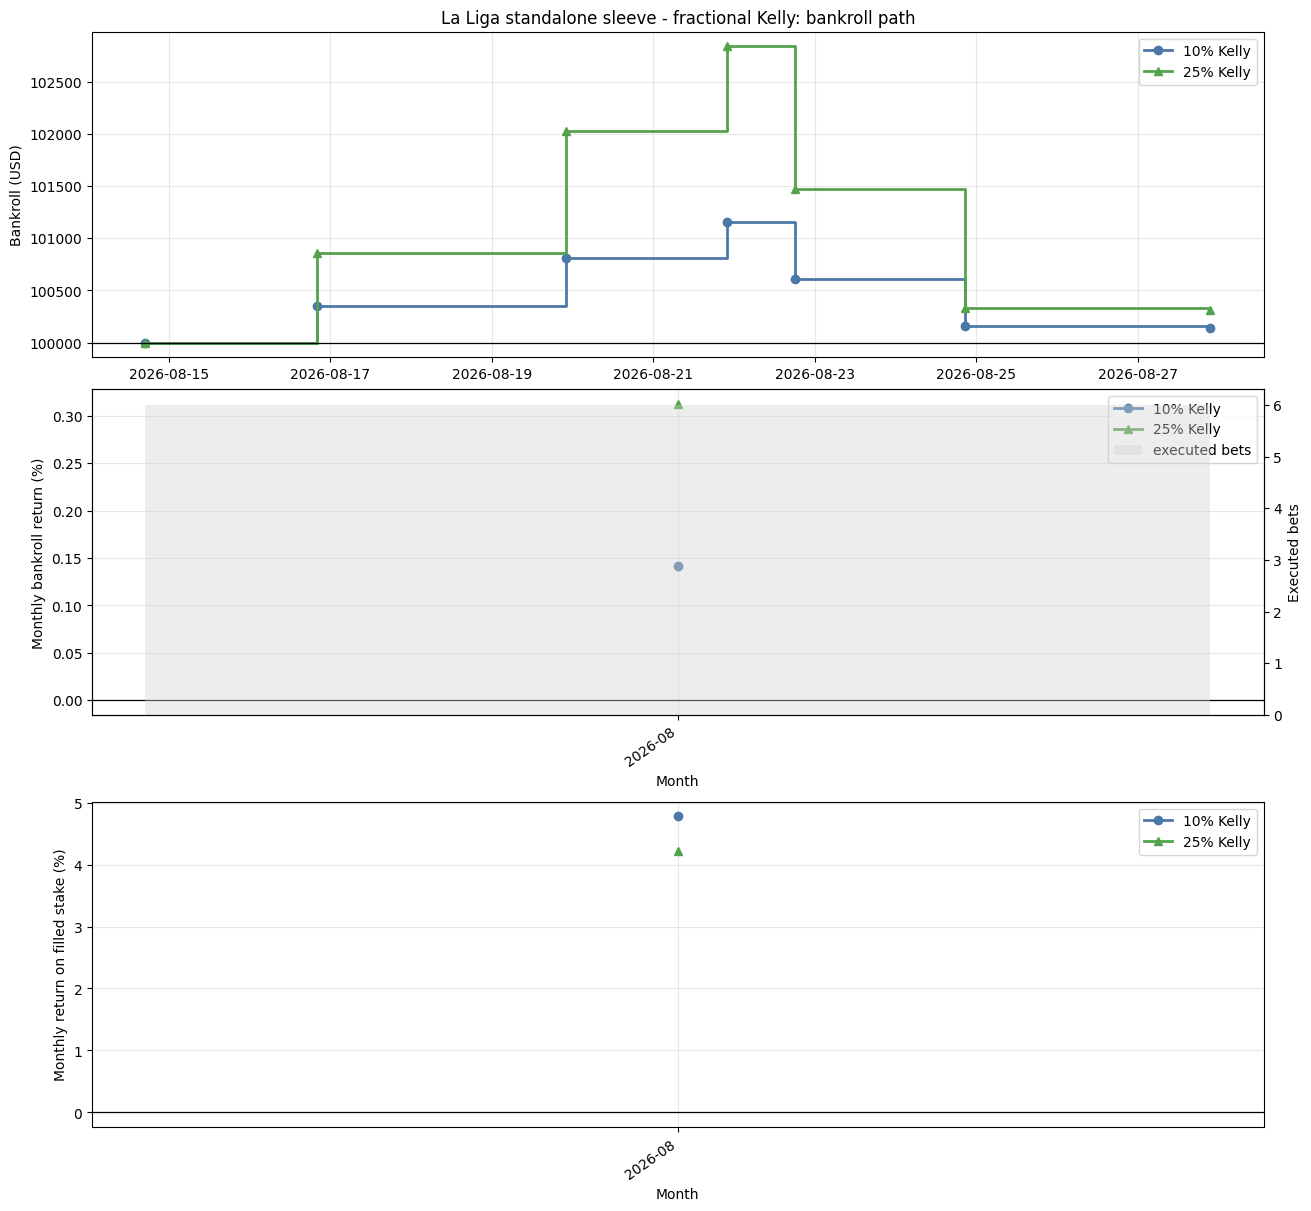

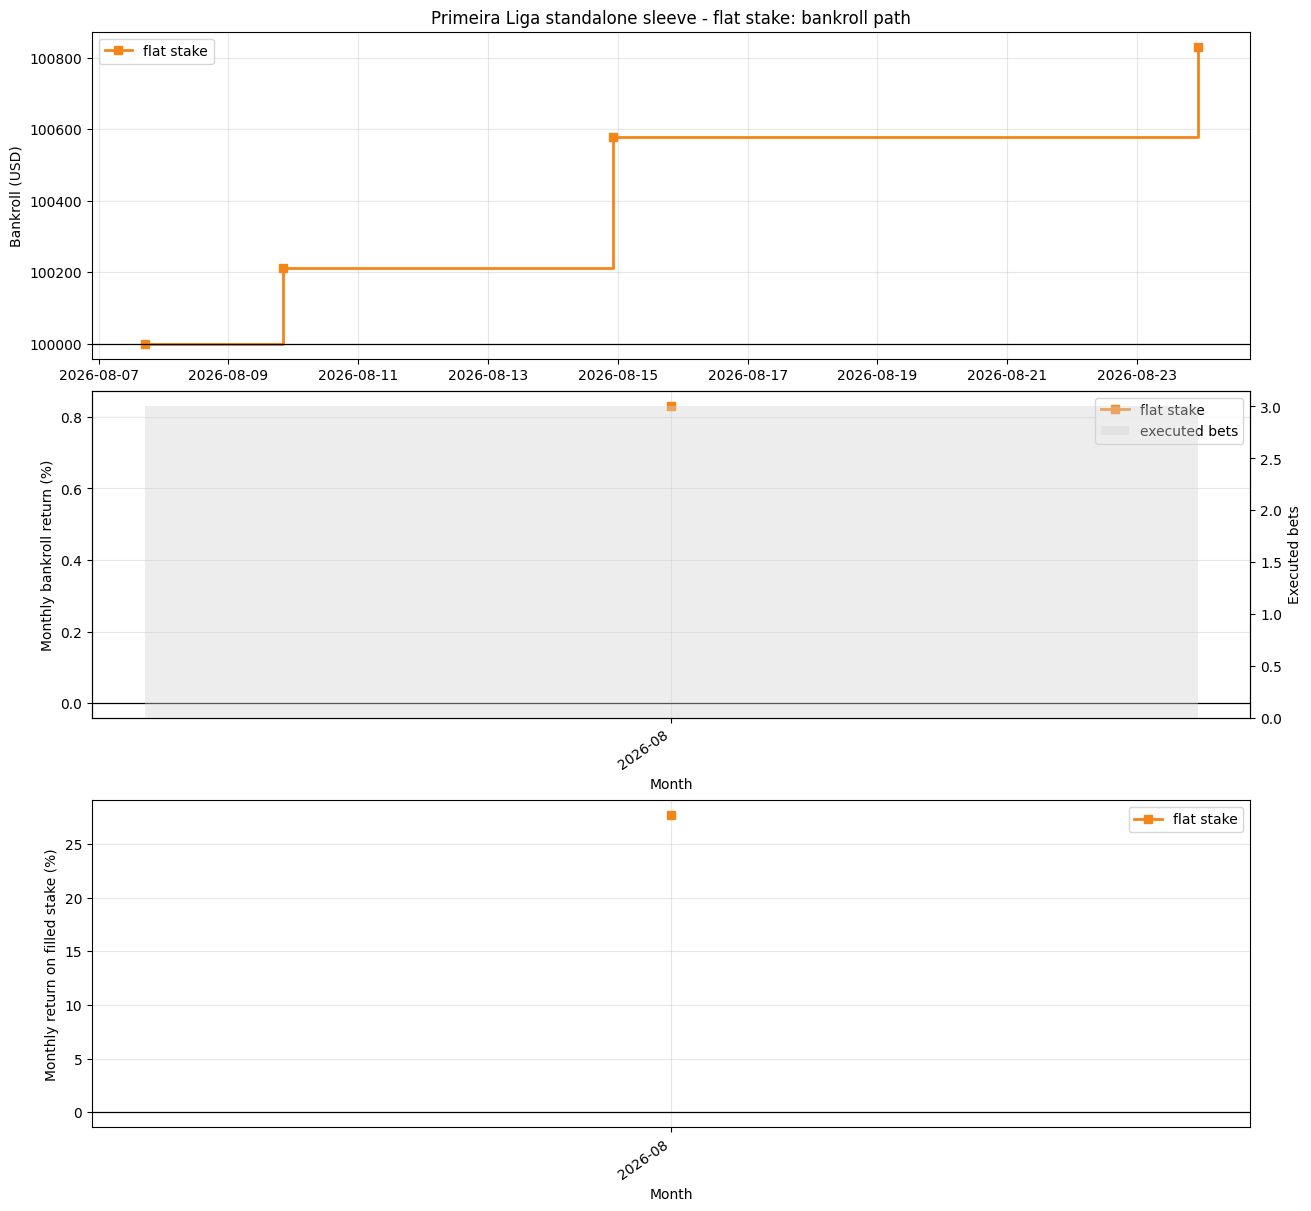

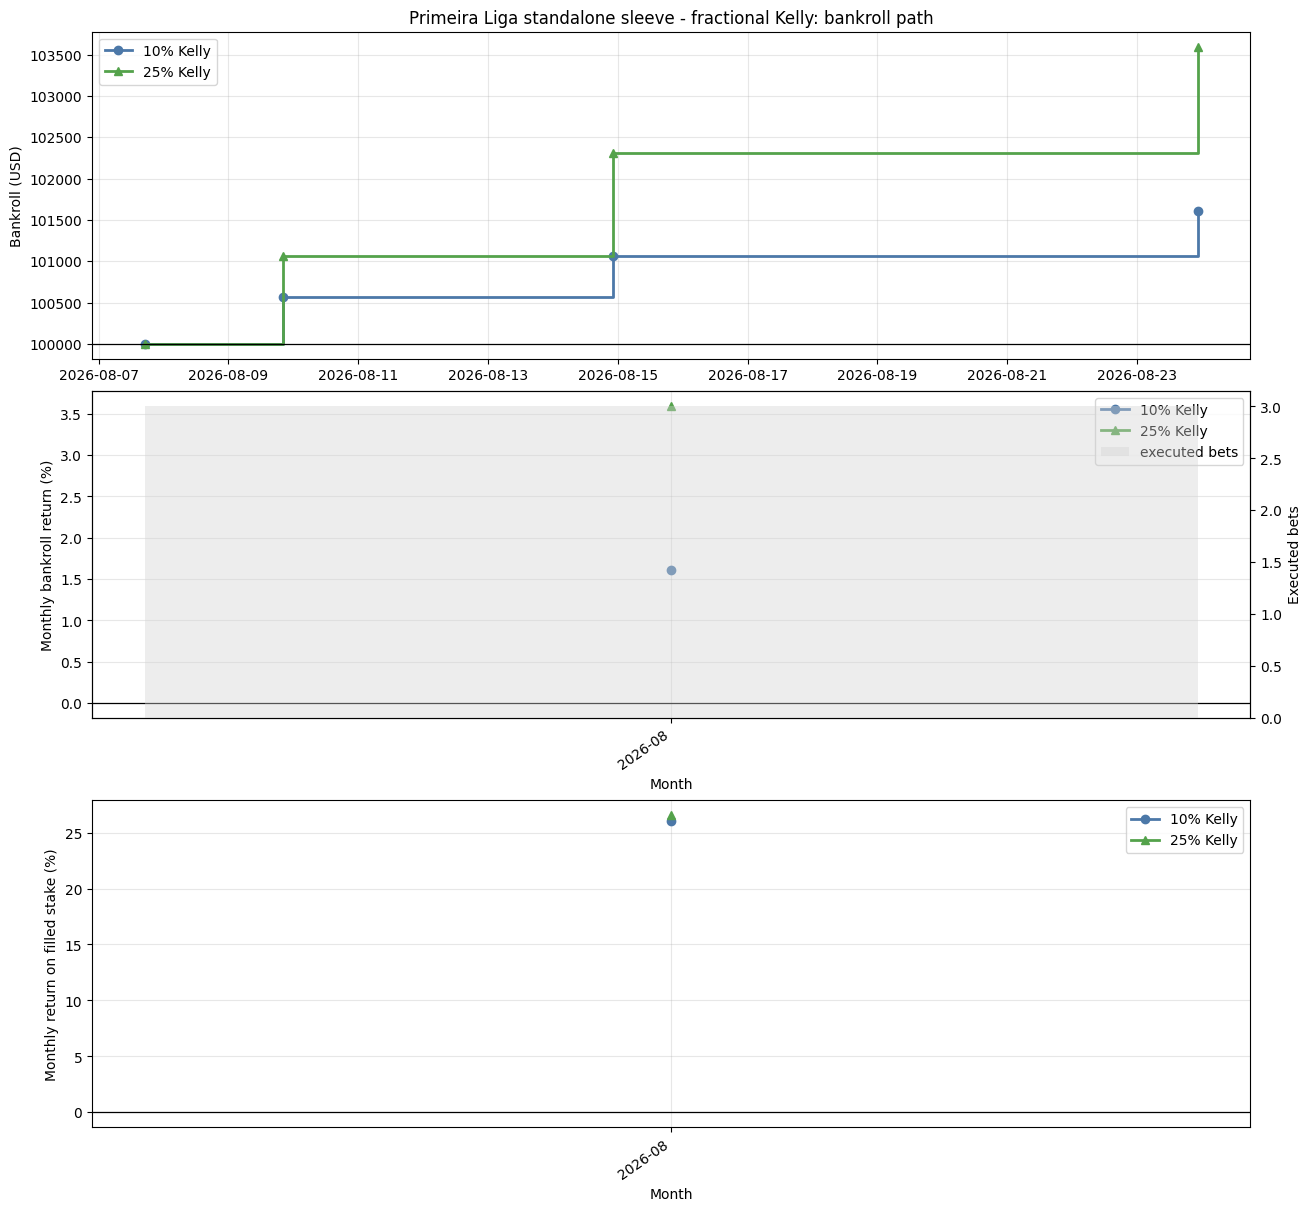

In [7]:
league_evaluation = evaluate_execution_by_league(
    execution_trades,
    config=EXECUTION_CONFIG,
)

if league_evaluation.metrics.empty:
    print("No standalone league results are available.")
else:
    league_common_sample, league_strategy_metrics = separate_common_strategy_statistics(
        league_evaluation.metrics, group_columns=("analysis_league",)
    )
    if not league_common_sample.empty:
        print("Common execution/sample statistics within each league:")
        display(round_numeric_for_display(league_common_sample))
        league_metric_columns = ["analysis_league", *metric_columns]
    else:
        league_metric_columns = [
            "analysis_league", "strategy", "bets", "wins", "hit_rate_pct",
            *metric_columns[1:],
        ]
    league_strategy_metrics = order_strategy_rows_for_display(
        league_strategy_metrics, group_columns=("analysis_league",)
    )
    display(
        round_numeric_for_display(
            league_strategy_metrics.reindex(columns=league_metric_columns)
        )
    )

    for league in sorted(league_evaluation.metrics["analysis_league"].unique()):
        league_paths = league_evaluation.simulation.bankroll_paths.loc[
            league_evaluation.simulation.bankroll_paths["analysis_league"].eq(league)
        ]
        league_monthly = league_evaluation.monthly_returns.loc[
            league_evaluation.monthly_returns["analysis_league"].eq(league)
        ]
        plot_forward_execution_results(
            league_paths,
            league_monthly,
            strategies=["flat stake"],
            title=f"{league} standalone sleeve - flat stake",
            initial_capital_usd=EXECUTION_CONFIG.initial_capital_usd,
            reporting_timezone=EXECUTION_CONFIG.reporting_timezone,
        )
        plt.show()
        plot_forward_execution_results(
            league_paths,
            league_monthly,
            strategies=[f"{fraction:.0%} Kelly" for fraction in EXECUTION_CONFIG.kelly_fractions],
            title=f"{league} standalone sleeve - fractional Kelly",
            initial_capital_usd=EXECUTION_CONFIG.initial_capital_usd,
            reporting_timezone=EXECUTION_CONFIG.reporting_timezone,
        )
        plt.show()

## 7. Interpretation and limitations

- Football-Data and the frozen parameters determine match eligibility; Polymarket is used only as execution evidence.
- Order limits and Kelly target stakes are fixed using information available at the documented Football-Data release time. Transactions and settlements are then processed chronologically.
- Historical taker BUY / maker SELL flow uses the observed raw transaction price. Historical taker SELL / maker BUY flow must reach the predefined raw limit but is credited only at that limit.
- The same configured buyer-side taker-style fee is applied exactly once to both execution types. Recorded historical fees remain diagnostic fields and are not added again.
- The minimum odds premium changes execution eligibility only. It does not change Football-Data match selection or the frozen model probability.
- `maximum_trade_participation` limits the share of each observed transaction attributed to the strategy, but it cannot reconstruct order priority or guarantee a fill.
- Dune transaction history is not a historical order book. Queue position, contemporaneous depth, cancellations, latency, and adverse selection remain unobserved.
- Exact final-whistle timestamps are unavailable; settlement is approximated at the configured number of hours after kickoff.
- Weekly volatility and Sharpe are annualized with $\sqrt{52}$ and are unstable while the forward sample remains short.
- Missing or unresolved outcomes are excluded from settlement reporting, not from the original Football-Data signal. Completed monthly workbooks should therefore be checked for outcome completeness.

The outputs should be interpreted as a frozen, auditable transaction-based execution simulation—not as proof of live executable capacity or future profitability.